# The "Last Mile" Logistics Auditor
## Veridi Logistics - Delivery Performance Audit

The question from the business: are we failing specific regions, or is delivery
performance a nationwide problem? The suspicion is that estimated delivery dates are
inaccurate (over-promising) and that this drives negative reviews.

This notebook works through the Olist Brazilian e-commerce dataset to answer that:

1. Join Orders, Reviews and Customers into one master table at the order level
2. Compare estimated vs actual delivery dates and classify On Time / Late / Super Late
3. Find which states have the worst late rates
4. Test whether lateness actually drives lower review scores
5. Bonus: translate the Portuguese product categories to English
6. Candidate's choice: split delivery time into handling vs transit to locate the bottleneck

The final step writes a small cleaned `orders_clean.parquet` that feeds the dashboard, so
the full raw dataset never has to be committed.

## Setup

In [1]:
%pip install -q pyarrow kagglehub  # noqa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 60)

## 1. Load the data

Default path is to upload the six Olist CSVs (drag them into the Colab Files panel). The
loader below finds them wherever they land. Set `USE_KAGGLEHUB = True` to pull the dataset
straight from Kaggle instead.

In [3]:
USE_KAGGLEHUB = False

CSV_FILES = [
    "olist_orders_dataset.csv", "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv", "olist_products_dataset.csv",
    "olist_order_items_dataset.csv", "product_category_name_translation.csv",
]

def find_data_dir():
    for d in ["data/raw", "/content", "/content/data/raw", ".", "data"]:
        if os.path.exists(os.path.join(d, CSV_FILES[0])):
            return d
    raise FileNotFoundError(
        "Olist CSVs not found. Upload the six files or set USE_KAGGLEHUB = True.")

if USE_KAGGLEHUB:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
else:
    DATA_DIR = find_data_dir()
print("Reading data from:", DATA_DIR)

def load(name):
    return pd.read_csv(os.path.join(DATA_DIR, name))

Reading data from: data/raw


In [4]:
orders      = load("olist_orders_dataset.csv")
reviews     = load("olist_order_reviews_dataset.csv")
customers   = load("olist_customers_dataset.csv")
products    = load("olist_products_dataset.csv")
order_items = load("olist_order_items_dataset.csv")
translation = load("product_category_name_translation.csv")

for name, df in [("orders", orders), ("reviews", reviews), ("customers", customers),
                 ("products", products), ("order_items", order_items),
                 ("translation", translation)]:
    print(f"{name:13s} {df.shape}")

orders        (99441, 8)
reviews       (99224, 7)
customers     (99441, 5)
products      (32951, 9)
order_items   (112650, 7)
translation   (71, 2)


In [5]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Story 1: build the master table

Target grain is one row per order, carrying the customer location and the review score.
Orders-to-reviews and orders-to-items are both one-to-many, so each "many" side is collapsed
to one row per order before joining. Otherwise the joins inflate the row count and every
downstream percentage is wrong.

In [6]:
# One review per order: some orders have several, so keep the most recent answer.
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])
reviews_dedup = (
    reviews.sort_values("review_answer_timestamp")
           .drop_duplicates(subset="order_id", keep="last")
           [["order_id", "review_score", "review_comment_message"]]
)
print(len(reviews), "reviews ->", len(reviews_dedup), "after one-per-order")

99224 reviews -> 98673 after one-per-order


In [7]:
# Order-level product category comes from the order's first line item.
primary_item = (
    order_items.sort_values("order_item_id")
               .drop_duplicates(subset="order_id", keep="first")
               [["order_id", "product_id", "price", "freight_value"]]
)
# Full-order economics (summed across all items) for later use.
order_money = (
    order_items.groupby("order_id")
               .agg(order_value=("price", "sum"),
                    freight_value=("freight_value", "sum"),
                    n_items=("order_item_id", "count"))
               .reset_index()
)
primary_item = primary_item.merge(
    products[["product_id", "product_category_name"]], on="product_id", how="left"
)

In [8]:
master = (
    orders
    .merge(customers[["customer_id", "customer_city", "customer_state"]],
           on="customer_id", how="left")
    .merge(reviews_dedup, on="order_id", how="left")
    .merge(primary_item[["order_id", "product_category_name"]], on="order_id", how="left")
    .merge(order_money, on="order_id", how="left")
)

# Guard against accidental row inflation from the joins.
assert len(master) == len(orders), f"row count changed: {len(orders)} -> {len(master)}"
print(f"{len(orders)} orders in, {len(master)} rows out")
master.head(3)

99441 orders in, 99441 rows out


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,review_score,review_comment_message,product_category_name,order_value,freight_value,n_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,4.0,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas,29.99,8.72,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,4.0,Muito bom o produto.,perfumaria,118.70,22.76,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,5.0,NaN,automotivo,159.90,19.22,1.0


## Story 2: delivery delay

`days_difference = estimated_delivery_date - delivered_customer_date`. Positive means the
order arrived before the promised date, negative means it was late. `days_late` is the same
thing flipped to a positive "days past the promise" value for easier reading.

Orders that never reached the customer (cancelled, unavailable, or no delivery date) can't
have a meaningful delay, so they are flagged and excluded from the delay analysis.

In [9]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in date_cols:
    master[c] = pd.to_datetime(master[c], errors="coerce")

master["is_delivered"] = (
    (master["order_status"] == "delivered")
    & master["order_delivered_customer_date"].notna()
)
print(master["order_status"].value_counts())
print(f"\ndelivered and datable: {master['is_delivered'].sum():,} / {len(master):,}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

delivered and datable: 96,470 / 99,441


In [10]:
master["days_difference"] = (
    master["order_estimated_delivery_date"] - master["order_delivered_customer_date"]
).dt.days
master["days_late"] = (-master["days_difference"]).clip(lower=0)

def classify(diff):
    if pd.isna(diff):
        return "Undelivered/Unknown"
    if diff >= 0:
        return "On Time"
    if diff >= -5:
        return "Late"
    return "Super Late"

master["delivery_status"] = master["days_difference"].apply(classify)

delivered = master[master["is_delivered"]].copy()
print(delivered["delivery_status"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

delivery_status
On Time       91.9 %
Super Late     4.4 %
Late           3.7 %
Name: proportion, dtype: str


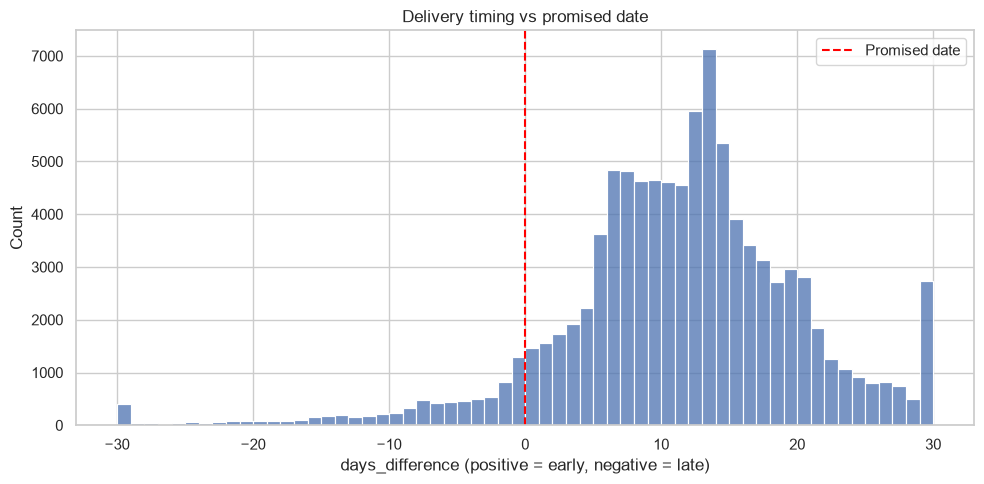

In [11]:
fig, ax = plt.subplots()
sns.histplot(delivered["days_difference"].clip(-30, 30), bins=60, ax=ax, color="#4C72B0")
ax.axvline(0, color="red", linestyle="--", label="Promised date")
ax.set_title("Delivery timing vs promised date")
ax.set_xlabel("days_difference (positive = early, negative = late)")
ax.legend()
plt.tight_layout()
plt.show()

Most of the mass sits to the right of zero: the majority of orders arrive before the promised
date. So the issue is not that Veridi is late on average, but a tail of badly-late orders that,
as the next story shows, is concentrated in particular states.

## Story 3: late deliveries by state

In [12]:
delivered["is_late"] = delivered["delivery_status"].isin(["Late", "Super Late"])

state_perf = (
    delivered.groupby("customer_state")
             .agg(orders=("order_id", "count"),
                  pct_late=("is_late", "mean"),
                  avg_days_late=("days_late", "mean"),
                  avg_review=("review_score", "mean"))
             .reset_index()
)
state_perf["pct_late"] = (state_perf["pct_late"] * 100).round(1)
state_perf = state_perf[state_perf["orders"] >= 50].sort_values("pct_late", ascending=False)
state_perf.head(10)

,customer_state,orders,pct_late,avg_days_late,avg_review
1,AL,397,23.9,2.282116,3.847716
9,MA,717,19.7,2.027894,3.832865
16,PI,476,16.0,2.010504,3.993631
5,CE,1279,15.3,2.242377,3.944226
24,SE,335,15.2,2.617910,3.907186
4,BA,3256,14.0,1.602580,3.930629
18,RJ,12350,13.5,1.771660,3.965441
26,TO,274,12.8,0.770073,4.153846
13,PA,946,12.4,1.560254,3.914255
7,ES,1995,12.2,1.334336,4.078720


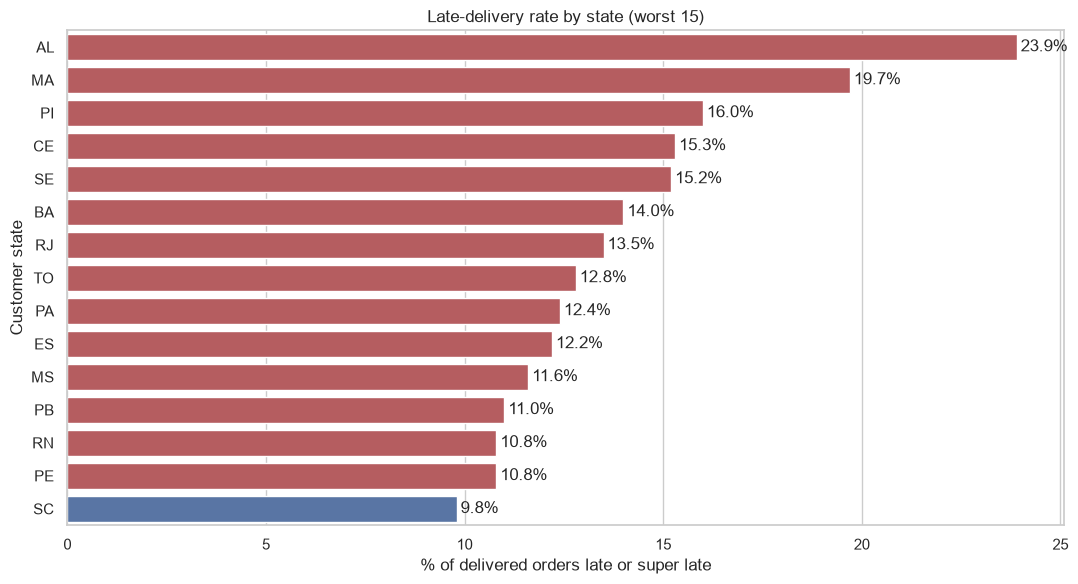

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
top = state_perf.head(15)
colors = ["#C44E52" if v >= state_perf["pct_late"].median() else "#4C72B0"
          for v in top["pct_late"]]
sns.barplot(data=top, y="customer_state", x="pct_late", palette=colors, ax=ax)
ax.set_title("Late-delivery rate by state (worst 15)")
ax.set_xlabel("% of delivered orders late or super late")
ax.set_ylabel("Customer state")
for i, v in enumerate(top["pct_late"]):
    ax.text(v + 0.1, i, f"{v}%", va="center")
plt.tight_layout()
plt.show()

In [14]:
# Compare remote northern / north-eastern states against the rest.
remote_states = ["RR", "AP", "AM", "AC", "PA", "RO", "MA", "TO", "AL", "PB"]
nat_avg = delivered["is_late"].mean() * 100
remote_avg = delivered[delivered["customer_state"].isin(remote_states)]["is_late"].mean() * 100
core_avg = delivered[~delivered["customer_state"].isin(remote_states)]["is_late"].mean() * 100
print(f"national late rate: {nat_avg:.1f}%")
print(f"remote (N/NE):      {remote_avg:.1f}%")
print(f"core (SE/S/CW):     {core_avg:.1f}%")
print(f"remote is {remote_avg / core_avg:.1f}x the core rate")

national late rate: 8.1%
remote (N/NE):      13.7%
core (SE/S/CW):     7.9%
remote is 1.7x the core rate


## Story 4: lateness vs review score

                     mean  count
delivery_status                 
On Time          4.294114  88163
Late             3.460482   3568
Super Late       1.784510   4093


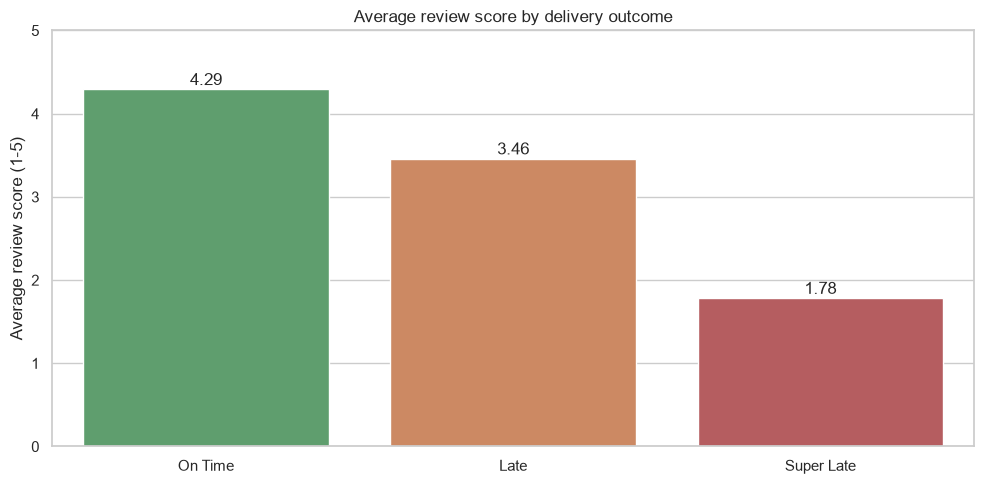

In [15]:
sent = (delivered.dropna(subset=["review_score"])
                 .groupby("delivery_status")["review_score"]
                 .agg(["mean", "count"])
                 .reindex(["On Time", "Late", "Super Late"]))
print(sent)

fig, ax = plt.subplots()
sns.barplot(x=sent.index, y=sent["mean"], palette=["#55A868", "#DD8452", "#C44E52"], ax=ax)
ax.set_title("Average review score by delivery outcome")
ax.set_ylabel("Average review score (1-5)")
ax.set_xlabel("")
ax.set_ylim(0, 5)
for i, v in enumerate(sent["mean"]):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

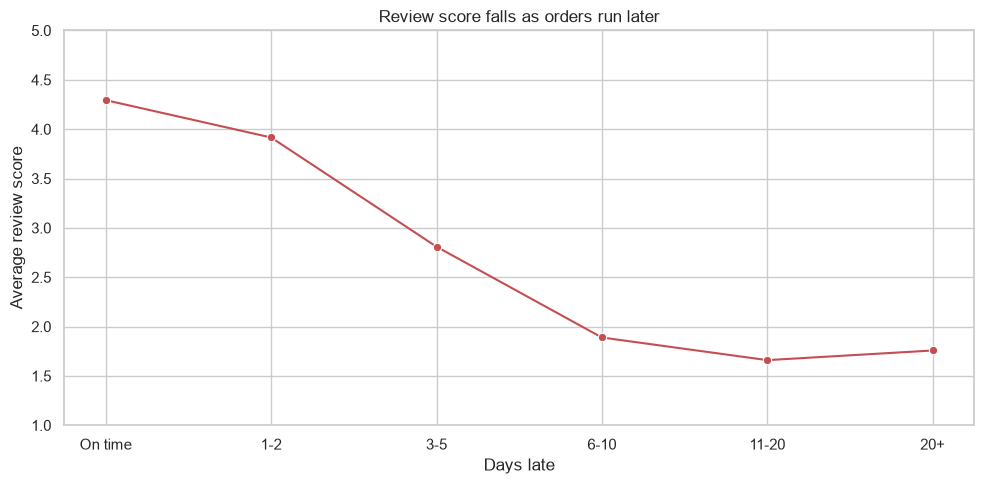

correlation days_late vs review_score: -0.276


In [16]:
tmp = delivered.dropna(subset=["review_score"]).copy()
tmp["late_bucket"] = pd.cut(
    tmp["days_late"], bins=[-1, 0, 2, 5, 10, 20, 1000],
    labels=["On time", "1-2", "3-5", "6-10", "11-20", "20+"]
)
bucket = tmp.groupby("late_bucket")["review_score"].mean()

fig, ax = plt.subplots()
sns.lineplot(x=range(len(bucket)), y=bucket.values, marker="o", ax=ax, color="#C44E52")
ax.set_xticks(range(len(bucket)))
ax.set_xticklabels(bucket.index)
ax.set_title("Review score falls as orders run later")
ax.set_xlabel("Days late")
ax.set_ylabel("Average review score")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

corr = tmp["days_late"].corr(tmp["review_score"])
print(f"correlation days_late vs review_score: {corr:.3f}")

Review scores drop sharply once an order is late and collapse for super-late orders. The
negative correlation confirms lateness is a direct driver of dissatisfaction.

## Bonus: translate product categories to English

In [17]:
master = master.merge(translation, on="product_category_name", how="left")
master["product_category"] = (
    master["product_category_name_english"]
    .fillna(master["product_category_name"])
    .fillna("unknown")
)
delivered = master[master["is_delivered"]].copy()
delivered["is_late"] = delivered["delivery_status"].isin(["Late", "Super Late"])
print(master[["product_category_name", "product_category"]].drop_duplicates().head(8))

   product_category_name  product_category
0  utilidades_domesticas        housewares
1             perfumaria         perfumery
2             automotivo              auto
3               pet_shop          pet_shop
4              papelaria        stationery
6                    NaN           unknown
8       moveis_decoracao   furniture_decor
9      moveis_escritorio  office_furniture


## Candidate's choice: where does the delay come from?

Knowing an order is late doesn't say how to fix it. Splitting total delivery time into two
stages does:

- handling time = carrier_date - purchase (how long the seller takes to dispatch)
- transit time = customer_date - carrier_date (how long the carrier takes to deliver)

If late orders lose their time in handling, the fix is seller SLAs; if in transit, it's
carrier capacity. The split below points clearly at one of them.

                handling_time  transit_time
is_late                                    
On-time orders            2.5           7.4
Late orders               5.4          25.2

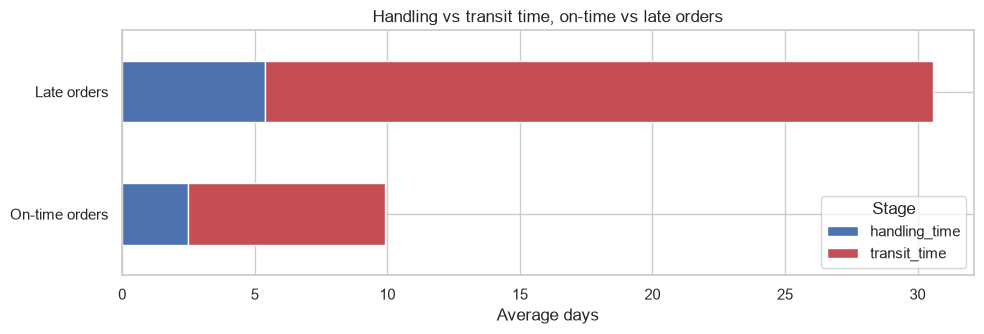

In [18]:
delivered["handling_time"] = (
    delivered["order_delivered_carrier_date"] - delivered["order_purchase_timestamp"]
).dt.days
delivered["transit_time"] = (
    delivered["order_delivered_customer_date"] - delivered["order_delivered_carrier_date"]
).dt.days
delivered["total_delivery_time"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days

pipe = (delivered.groupby("is_late")[["handling_time", "transit_time"]]
                 .mean().round(1)
                 .rename(index={False: "On-time orders", True: "Late orders"}))
print(pipe)

pipe.plot(kind="barh", stacked=True, color=["#4C72B0", "#C44E52"], figsize=(10, 3.5))
plt.title("Handling vs transit time, on-time vs late orders")
plt.xlabel("Average days")
plt.ylabel("")
plt.legend(title="Stage")
plt.tight_layout()
plt.show()

In [19]:
worst = state_perf.head(8)["customer_state"].tolist()
pipe_state = (delivered[delivered["customer_state"].isin(worst)]
              .groupby("customer_state")[["handling_time", "transit_time"]]
              .mean().round(1).sort_values("transit_time", ascending=False))
print(pipe_state)

                handling_time  transit_time
customer_state                             
AL                        3.0          20.6
CE                        2.9          17.5
MA                        3.1          17.5
SE                        3.1          17.5
PI                        2.7          15.8
BA                        2.8          15.6
TO                        2.9          13.8
RJ                        2.8          11.6


For late and remote orders the extra days are in transit, not handling. Sellers dispatch on
time but the carrier leg to far states is slow, so the action is regional carrier capacity
and hubs rather than seller SLAs.

## Export the cleaned dataset for the dashboard

In [20]:
export_cols = [
    "order_id", "order_status", "is_delivered",
    "customer_city", "customer_state",
    "order_purchase_timestamp", "order_estimated_delivery_date",
    "order_delivered_customer_date",
    "days_difference", "days_late", "delivery_status",
    "review_score", "product_category",
    "order_value", "freight_value", "n_items",
]
clean = master[export_cols].copy()
clean = clean.merge(
    delivered[["order_id", "handling_time", "transit_time", "total_delivery_time", "is_late"]],
    on="order_id", how="left"
)

os.makedirs("data/processed", exist_ok=True)
out_path = "data/processed/orders_clean.parquet"
clean.to_parquet(out_path, index=False)
print(f"wrote {out_path} ({len(clean):,} rows, {os.path.getsize(out_path)/1e6:.1f} MB)")
clean.head(3)

wrote data/processed/orders_clean.parquet (99,441 rows, 6.5 MB)


,order_id,order_status,is_delivered,customer_city,customer_state,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,days_difference,days_late,delivery_status,review_score,product_category,order_value,freight_value,n_items,handling_time,transit_time,total_delivery_time,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,True,sao paulo,SP,2017-10-02 10:56:33,2017-10-18,2017-10-10 21:25:13,7.0,0.0,On Time,4.0,housewares,29.99,8.72,1.0,2.0,6.0,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,True,barreiras,BA,2018-07-24 20:41:37,2018-08-13,2018-08-07 15:27:45,5.0,0.0,On Time,4.0,perfumery,118.70,22.76,1.0,1.0,12.0,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,True,vianopolis,GO,2018-08-08 08:38:49,2018-09-04,2018-08-17 18:06:29,17.0,0.0,On Time,5.0,auto,159.90,19.22,1.0,0.0,9.0,9.0,False


In [21]:
# On Colab, download the parquet so it can be committed alongside the dashboard.
try:
    from google.colab import files  # type: ignore
    files.download(out_path)
except Exception:
    print("Not on Colab - parquet is in the local data/processed/ folder.")

Not on Colab - parquet is in the local data/processed/ folder.


## Key findings

In [22]:
on_time_review = sent.loc["On Time", "mean"]
late_review = sent.loc[["Late", "Super Late"], "mean"].mean()
print("delivered orders analysed:", f"{len(delivered):,}")
print("on-time rate:", f"{(delivered['delivery_status']=='On Time').mean()*100:.1f}%")
print("late + super-late rate:", f"{delivered['is_late'].mean()*100:.1f}%")
print(f"worst state ({state_perf.iloc[0]['customer_state']}):", f"{state_perf.iloc[0]['pct_late']}%")
print("avg review on time:", f"{on_time_review:.2f}")
print("avg review late:", f"{late_review:.2f}")
print("days_late vs review correlation:", f"{corr:.3f}")

delivered orders analysed: 96,470
on-time rate: 91.9%
late + super-late rate: 8.1%
worst state (AL): 23.9%
avg review on time: 4.29
avg review late: 2.62
days_late vs review correlation: -0.276
